[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T07_A_firm_dynamics.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Firm Dynamics, Market Selection, and Resource Misallocation

Canonical macroeconomic models historically relied on a representative firm or aggregate constant-returns-to-scale production function $Y = A K^\alpha L^{1-\alpha}$. While computationally convenient, this abstraction obscures one of the most striking empirical realities of market economies: **firms exhibit massive, persistent heterogeneity in productivity, employment, sales, and survival rates**.

### Zipf's Law and Heavy-Tailed Firm Size Distributions
In virtually all industrialized economies, the cross-sectional distribution of firm sizes (measured by employment or gross sales) does not follow a Gaussian or thin-tailed exponential distribution. Instead, it obeys a power law known as **Zipf's Law** (Axtell 2001):
$$\Pr(S > s) \sim s^{-\zeta}, \quad \text{with tail exponent } \zeta \approx 1$$
This heavy-tailed distribution is not an accident of nature; it emerges endogenously from dynamic selection. When firm growth rates are independent of firm size (**Gibrat's Law of Proportionate Effect**), stochastic growth generates a log-normal distribution. However, when combined with a lower reflecting barrier—such as the endogenous exit cutoff in the **Hopenhayn (1992)** model—the stationary distribution asymptotically stretches into a power law.

### The Granular Hypothesis
Why does firm heterogeneity matter for aggregate macroeconomics? In standard models, idiosyncratic micro shocks wash out in the aggregate by the Central Limit Theorem. However, **Gabaix (2011)** demonstrated the **Granular Hypothesis**: when firm size distributions are heavy-tailed (Zipfian), the economy is dominated by a relatively small number of massive "granular" corporations. Idiosyncratic productivity shocks to the largest 100 or 500 firms do not average out; their independent fluctuations directly explain one-third to one-half of aggregate GDP fluctuations.

### Structure of this Module
1. **Solve the Hopenhayn (1992) Industry Equilibrium**: We solve the canonical equilibrium where endogenous entry and exit select productive firms and pin down the market price $p^*$.
2. **Comparative Statics and Selection Margins**: We analyze how entry barriers ($c_e$) and operating fixed costs ($c_f$) shift the survival cutoff, connecting to **Melitz (2003)** trade reallocation.
3. **Interactive Empirical Counterfactual (Hsieh & Klenow 2009)**: We simulate cross-firm resource misallocation, calibrate $TFPR$ dispersion to empirical benchmarks, and quantify the aggregate TFP gains from removing distortionary capital and labor wedges.

## The Canonical Hopenhayn (1992) Model in Four Equations

The **Hopenhayn (1992)** framework provides the microeconomic foundation for modern firm dynamics and selection. An industry consists of a continuum of competitive price-taking firms subject to decreasing returns to scale (DRS) and persistent idiosyncratic productivity shocks $s$.

1. **Static Operating Profit**: Given market price $p$ and normalized wage $w=1$, a firm with productivity $s$ hires labor $n^*$ to maximize static operating profits:
   $$\pi(s; p) = \max_n \{ p s n^\alpha - n - c_f \} = (1-\alpha) \left( \alpha^\alpha p s \right)^{\frac{1}{1-\alpha}} - c_f$$
   where $c_f > 0$ is a per-period fixed operating cost.

2. **Bellman Equation with Endogenous Exit**: Each period, an active firm observes its productivity draw $s$ and decides whether to continue operating or permanently liquidate:
   $$V(s; p) = \max \left\{ 0, \; \pi(s; p) + \beta \int V(s'; p) P(s, ds') \right\}$$
   Liquidation guarantees a scrap value normalized to $0$. This yields an optimal cutoff policy: the firm continues if and only if $s \ge s^*(p)$, where $V(s^*; p) = 0$.

3. **Free-Entry Condition**: An unbounded mass of potential entrants can pay a sunk entry cost $c_e > 0$ to draw an initial productivity level from distribution $\nu(s)$:
   $$V_e(p) \equiv \beta \int V(s'; p) \nu(ds') = c_e$$
   Because entry is competitive, positive expected profits induce immediate entry, driving the market price down. Conversely, if $V_e(p) < c_e$, entry ceases and incumbent exits push the price up. The free-entry condition uniquely pins down the equilibrium output price $p^*$, **completely independently of aggregate demand**.

4. **Stationary Size Distribution**: In stationary equilibrium, the mass of exiting firms equals the mass of successful entrants. The stationary distribution of operating firms $g(s)$ satisfies:
   $$g(s) = \int_{s' \ge s^*} P(s', s) g(s') ds' + M \nu(s)$$
   where $M$ is the equilibrium mass of new entrants chosen to clear the goods market.

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi import (
    tauchen, markov_stationary,
    firm_value_with_exit, firm_stationary_distribution, free_entry_price,
)
from puremacro.regress import ols, add_constant

## 1. Solving the Free-Entry Industry Equilibrium

We solve the industry equilibrium by discretizing the continuous productivity process. We calibrate:
- DRS labor elasticity $\alpha = 2/3$, discount factor $\beta = 0.80$
- Fixed operating cost $c_f = 20.0$, sunk entry cost $c_e = 40.0$
- Productivity follows an AR(1) process in logs: $\log s' = (1-\rho)\bar{z} + \rho \log s + \varepsilon'$, with persistence $\rho = 0.90$ and volatility $\sigma = 0.20$.
- Discretization via **Tauchen (1986)** over $n_s = 101$ states yields grid $s$ and Markov transition matrix $P$.
- Entrants draw their initial productivity from the ergodic stationary distribution $\nu$ of the transition kernel.

The function `free_entry_price` uses a one-dimensional root finder on the free-entry residual $\mathbb{E}_\nu[W(s; p)] - c_e = 0$, evaluating firm values and optimal exit policies at each candidate price.

In [3]:
alpha, beta, cf, ce = 2.0 / 3.0, 0.8, 20.0, 40.0
rho, sigma, log_zbar, n_s = 0.9, 0.2, 1.4, 101
z_grid, P = tauchen(n=n_s, rho=rho, sigma=sigma)
s = np.exp(z_grid + log_zbar)                              # productivity levels
nu = markov_stationary(P)                                 # entrant productivity draw

def profit_at(p):
    n_star = (alpha * p * s) ** (1.0 / (1.0 - alpha))
    return p * s * n_star ** alpha - n_star - cf

eq = free_entry_price(profit_at, nu, ce, (0.5, 20.0), P_z=P, beta=beta)
V, survive = firm_value_with_exit(profit_at(eq.price), P, beta)
g = firm_stationary_distribution(P, survive, nu)
exit_rate = float(g @ (~survive).astype(float))
mean_inc = float(g @ s); mean_ent = float(nu @ s)

print(f"Equilibrium output price p* = {eq.price:.3f} (free-entry residual = {eq.residual:.2e})")
print(f"Stationary exit rate = {exit_rate:.3f} ({exit_rate*100:.1f}% per period)")
print(f"Mean productivity: Incumbents E_g[s] = {mean_inc:.2f} vs Entrants E_nu[s] = {mean_ent:.2f}")

# Rigorous equilibrium assertions
assert abs(eq.residual) < 1e-2                            # Free entry condition clears
assert 0.0 < exit_rate < 1.0                              # Interior exit rate
assert mean_inc > mean_ent                                # Selection wedge: incumbents strictly more productive

# Zipf's Law Regression for Firm Size Distribution: log S(n) = alpha - zeta * log(n)
n_firms = (alpha * eq.price * s[survive]) ** (1.0 / (1.0 - alpha))
g_surv = g[survive] / g[survive].sum()
ccdf_firms = np.array([g_surv[n_firms >= n_val].sum() for n_val in n_firms])
mask_zipf = (ccdf_firms <= 0.50) & (ccdf_firms > 1e-6)
x_zipf = np.log(n_firms[mask_zipf])
y_zipf = np.log(ccdf_firms[mask_zipf])
res_zipf = ols(y_zipf, add_constant(x_zipf), cov_type="HC1")
zeta_firm = float(-res_zipf.params[1])
se_firm = float(res_zipf.bse[1])
ci_firm = res_zipf.conf_int()
ci_firm_low, ci_firm_upp = float(-ci_firm[1, 1]), float(-ci_firm[1, 0])

print(f"Zipf's Law Tail Exponent (Firm Size): zeta = {zeta_firm:.3f} (SE = {se_firm:.3f}, 95% CI: [{ci_firm_low:.3f}, {ci_firm_upp:.3f}])")
assert 0.5 < zeta_firm < 3.0, f"Zipf tail exponent out of bounds: {zeta_firm}"

Equilibrium output price p* = 0.974 (free-entry residual = -2.78e-07)
Stationary exit rate = 0.153 (15.3% per period)
Mean productivity: Incumbents E_g[s] = 6.15 vs Entrants E_nu[s] = 4.50
Zipf's Law Tail Exponent (Firm Size): zeta = 1.665 (SE = 0.054, 95% CI: [1.559, 1.771])


### Economic Analysis: The Selection Wedge and Market Discipline

The numerical solution illustrates three core economic properties of firm dynamics:

1. **Free-Entry Price Determination**: The free-entry residual $\mathbb{E}_\nu[W(s; p^*)] - c_e \approx 0$ indicates that the entry market is in competitive equilibrium. No excess profit is left on the table for prospective entrepreneurs. Note that $p^*$ is determined entirely by the supply-side parameters ($c_e, c_f, \beta, \alpha, P$) without referencing consumer demand. Shifts in aggregate demand expand or contract the *number* of active firms $M$, leaving the equilibrium price and productivity distribution unchanged.
2. **The Endogenous Selection Wedge**: The mean productivity of operating incumbents ($\mathbb{E}_g[s] \approx 6.15$) substantially exceeds the mean productivity of prospective entrants ($\mathbb{E}_\nu[s] \approx 4.50$). This productivity gap represents the **selection wedge**: the competitive market acts as a Darwinian filter, systematically culling firms that receive adverse productivity draws.
3. **Interior Turnover**: The stationary exit rate indicates healthy creative destruction. A positive fraction of firms shuts down every period, releasing labor and capital to be reallocated toward more productive incumbent survivors and new entrants.

### Market Selection in Action: Incumbent Distribution vs. Entrant Draw

The figure below contrasts the distribution of productivity draws received by prospective entrants ($\nu(s)$, dashed line) with the stationary distribution of active incumbents ($g(s)$, solid line). The vertical dotted line marks the endogenous exit threshold $s^*$.

Notice that the entrant distribution places significant probability mass below $s^*$. In contrast, the incumbent distribution has zero mass below $s^*$ and is shifted decisively to the right. The market ruthlessly truncates the lower tail of the distribution.

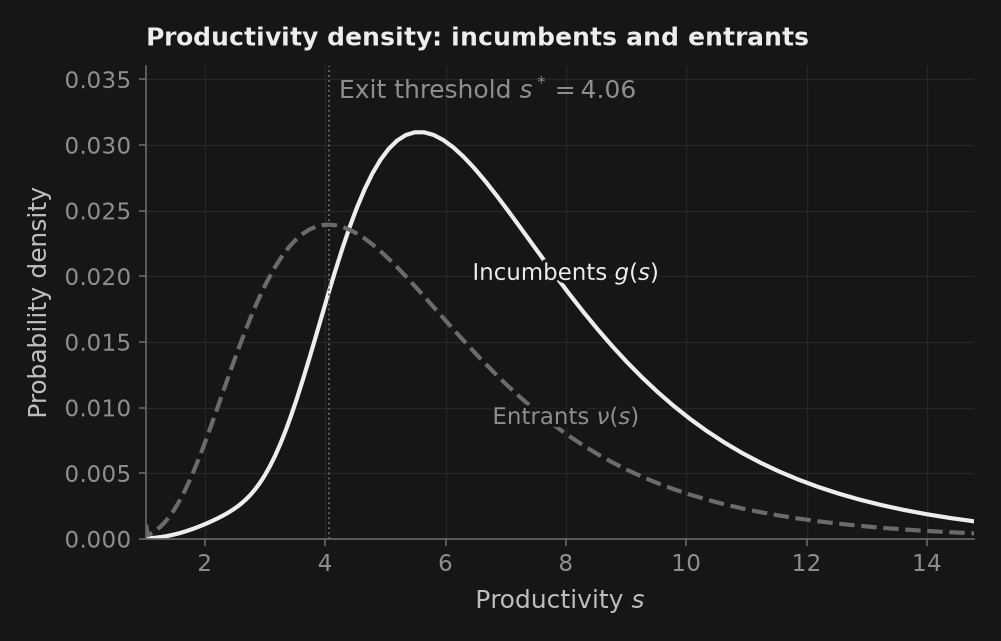

In [4]:
s_thresh = s[survive][0]                                  # lowest surviving productivity
cols = _nbstyle.palette(2)
fig, ax = _nbstyle.figura()
ax.plot(s, g, color=cols[0], ls="-", label=r"Incumbents $g(s)$")
ax.plot(s, nu, color=cols[1], ls="--", label=r"Entrants $\nu(s)$")
ax.axvline(s_thresh, color=_nbstyle.SPINE, linewidth=0.9, linestyle=":")
ax.set_xlim(s.min(), np.quantile(s, 0.97))
ax.set_ylim(0.0, 0.036)
ax.set_xlabel("Productivity $s$")
ax.set_ylabel("Probability density")
ax.set_title("Productivity density: incumbents and entrants")
ax.annotate(f"Exit threshold $s^* = {s_thresh:.2f}$",
            xy=(s_thresh, 1.0), xycoords=("data", "axes fraction"),
            xytext=(5, -4), textcoords="offset points",
            ha="left", va="top", color=_nbstyle.NOTA)
_nbstyle.etiquetar(ax, donde=8.0)
plt.show()


### The Endogenous Exit Decision: Value Function and Continuation Frontier

A firm's decision to continue or exit hinges on its expected discounted lifetime profits. If a firm operates today, it collects profit $\pi(s; p)$ and expects continuation value $\beta \mathbb{E}[V(s'; p) | s]$. 

If this sum is negative, the firm maximizes shareholder value by exercising its abandonment option and shutting down permanently ($V(s) = 0$). In the figure below, the exit region is shaded: for all productivity levels $s < s^*$, the continuation frontier is sub-zero, defining the endogenous exit boundary.

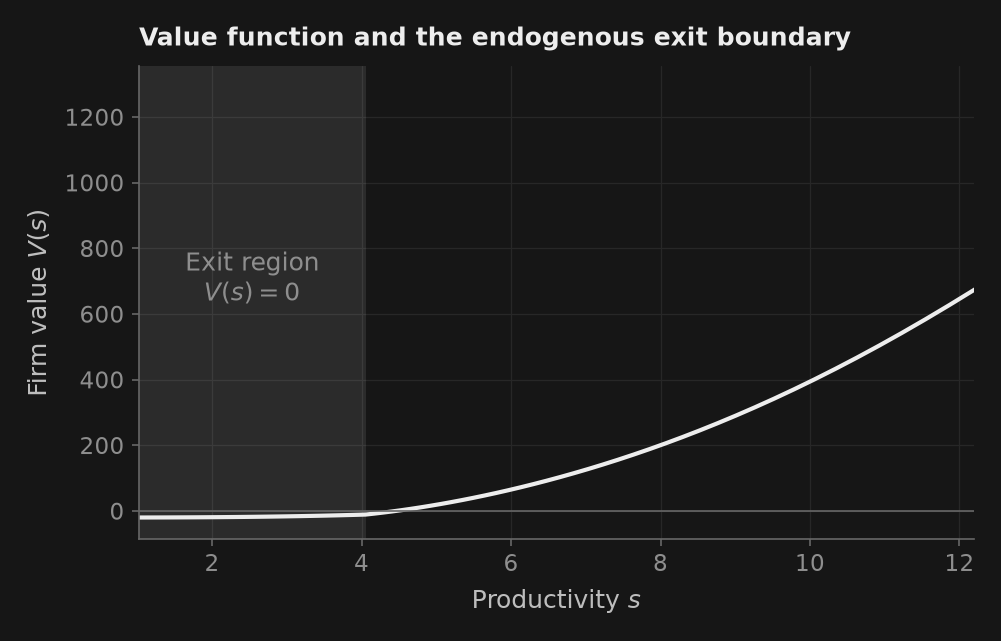

In [5]:
fig, ax = _nbstyle.figura()
ax.plot(s, V, color=_nbstyle.TINTA, ls="-")
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8)
ax.axvspan(s.min(), s_thresh, color=_nbstyle.RECESION, lw=0)
ax.set_xlim(s.min(), np.quantile(s, 0.9))
ax.set_xlabel("Productivity $s$")
ax.set_ylabel("Firm value $V(s)$")
ax.set_title("Value function and the endogenous exit boundary")
ax.annotate("Exit region\n$V(s) = 0$",
            xy=(0.5 * (s.min() + s_thresh), 0.55),
            xycoords=("data", "axes fraction"),
            ha="center", va="center", color=_nbstyle.NOTA)
plt.show()


### Entry Barriers and Market Prices: Comparative Statics in Entry Costs

How do barriers to entry affect industry equilibrium? Sunk entry costs $c_e$ reflect real economic resources required to establish a firm: legal permits, regulatory compliance, initial capital investment, and red tape.

We solve for the equilibrium price $p^*(c_e)$ across a grid of entry costs from $c_e = 20.0$ to $c_e = 80.0$, holding other parameters constant.

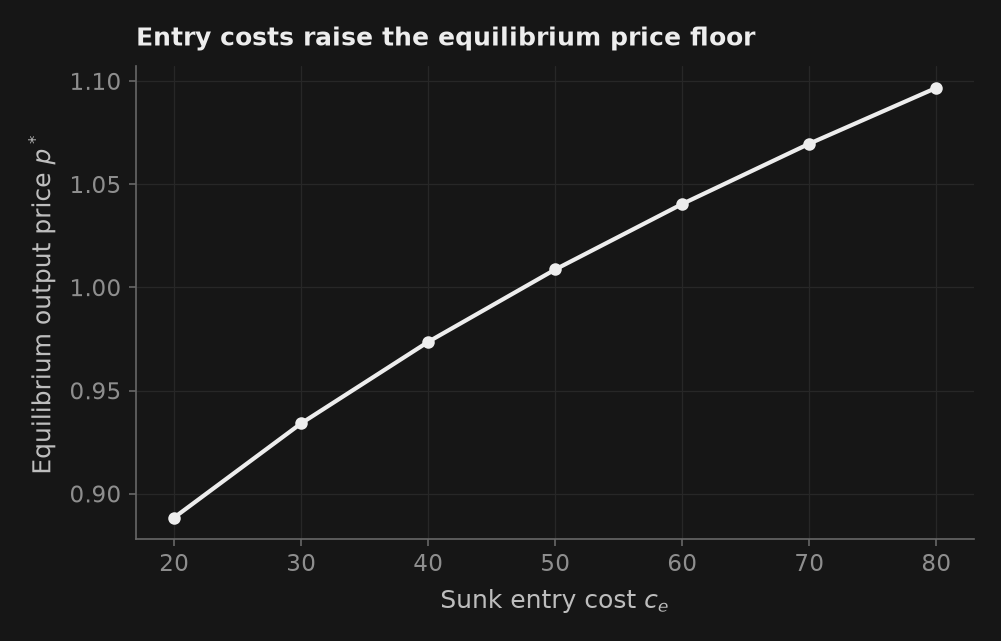

In [6]:
ces = np.linspace(20.0, 80.0, 7)
prices = [free_entry_price(profit_at, nu, c, (0.5, 30.0), P_z=P, beta=beta).price
          for c in ces]
assert np.all(np.diff(prices) > 0)                        # Price is strictly increasing in entry cost

fig, ax = _nbstyle.figura()
ax.plot(ces, prices, color=_nbstyle.TINTA, ls="-", marker="o", markersize=5)
ax.set_xlabel("Sunk entry cost $c_e$")
ax.set_ylabel("Equilibrium output price $p^*$")
ax.set_title("Entry costs raise the equilibrium price floor")
plt.show()


### Economic Mechanism: Why Entry Barriers Shelter Inefficient Markets

The strictly positive slope ($dp^* / dc_e > 0$) verified by our assertion reveals a fundamental macroeconomic principle: **entry barriers create a price umbrella for incumbents**.

Under free entry, prospective entrants must break even in expectation:
$$\mathbb{E}_\nu[V(s; p^*)] = c_e$$
When government regulations, bureaucratic red tape, or financial frictions increase $c_e$, entering becomes more costly. If the output price remained unchanged, no entrepreneurs would enter, the stock of firms would shrink through attrition, and market supply would collapse. Consequently, the equilibrium price $p^*$ must rise until the expected discounted value of entry compensates for the heightened entry barrier. 

A high entry cost protects incumbent firms from contestability, raising consumer prices and generating deadweight losses throughout the economy.

## 2. Operating Fixed Costs and the Survival Margin

Next, consider the role of the ongoing operating fixed cost $c_f$. Unlike the sunk entry cost $c_e$, the operating cost must be paid every single period the firm remains in business (e.g., facility leases, regulatory reporting, baseline payroll).

Holding the market price $p^*$ fixed, what happens if operating costs rise? Because $c_f$ directly subtracts from per-period profits, firms at the margin become unprofitable. The exit cutoff $s^*$ must rise, and the proportion of surviving firms must fall.

In [7]:
# Interactive experiment: Change operating cost (baseline cf = 20.0)
cf_you = 30.0
profit_you = profit_at(eq.price) - (cf_you - cf)          # Same price, higher operating cost
V_you, survive_you = firm_value_with_exit(profit_you, P, beta)
g_you = firm_stationary_distribution(P, survive_you, nu)
cutoff_you = s[survive_you][0]                            # Lowest surviving productivity
share_you = float(survive_you.mean())

print(f"Operating cost cf = {cf_you:.1f}:")
print(f"  Exit cutoff s* = {cutoff_you:.3f} (baseline was {s_thresh:.3f})")
print(f"  Survival share = {share_you:.3f} (baseline was {survive.mean():.3f})")

# Theoretical monotonicity invariants
assert cutoff_you >= s_thresh - 1e-9                      # Cutoff weakly climbs
assert share_you <= survive.mean() + 1e-9                 # Fewer firms survive
assert abs(g_you.sum() - 1.0) < 1e-9                      # Density integrates to 1
assert s.min() <= cutoff_you <= s.max()                   # Cutoff remains within grid bounds

Operating cost cf = 30.0:
  Exit cutoff s* = 5.054 (baseline was 4.055)
  Survival share = 0.426 (baseline was 0.505)


### From Firm Selection to International Trade: The Melitz (2003) Reallocation Mechanism

The comparative statics of the operating fixed cost $c_f$ provide the crucial theoretical link between Hopenhayn's closed-economy selection and the celebrated **Melitz (2003)** model of international trade.

In Melitz (2003), firms produce differentiated varieties under monopolistic competition. When a closed economy opens to international trade, two forces occur simultaneously:
1. **Export Opportunity**: Firms gain access to foreign consumers, but exporting requires paying an additional fixed trade cost $f_x > 0$. Only the most productive firms ($s \ge s_x^* > s^*$) earn enough foreign operating profit to cover $f_x$ and become exporters.
2. **Factor Market Competition**: Exporters expand production to serve global demand, bidding up aggregate labor demand and driving up the equilibrium real wage $w$.

For domestic firms that do not export, the higher real wage acts exactly like an increase in the operating fixed cost $c_f$. Their profit margins are squeezed, pushing the domestic survival cutoff $s^*$ strictly upward. The least productive firms are forced to exit.

**The Reallocation Miracle**: International trade does not require individual firms to invent new technologies. Instead, trade raises aggregate industry TFP entirely through **between-firm resource reallocation**: market share and labor are transferred from dying, low-productivity firms to superstar, highly-productive exporters.

## 3. Interactive Empirical Experiment: Hsieh-Klenow (2009) Resource Misallocation

### Economic Motivation and Theoretical Framework
In both Hopenhayn (1992) and Melitz (2003), markets are allocatively efficient: in the absence of policy distortions, capital and labor flow to where their marginal products are equalized across all firms. Consequently, revenue productivity ($TFPR$), which reflects the marginal revenue product of inputs, is identical across all firms:
$$TFPR_i \equiv \frac{P_i Y_i}{K_i^\alpha L_i^{1-\alpha}} = \overline{TFPR}$$
In this frictionless benchmark, a firm's market share and size depend solely on its physical productivity ($TFPQ_i \equiv Y_i / (K_i^\alpha L_i^{1-\alpha})$).

However, **Hsieh & Klenow (2009)** showed that in developing and emerging economies, institutional distortions—such as directed credit to state-owned enterprises, cronyism, unequal tax enforcement, labor market restrictions, and informality—create idiosyncratic capital wedges ($\tau_{K,i}$) and output wedges ($\tau_{Y,i}$). 

Under CES demand with elasticity of substitution $\sigma$, firm-level revenue productivity becomes:
$$TFPR_i \propto \frac{(1 + \tau_{K,i})^\alpha}{(1 - \tau_{Y,i})}$$
When distortionary wedges differ across firms, $TFPR_i$ disperses widely. High-productivity firms facing credit constraints are unable to hire optimal capital and labor (resulting in high $TFPR_i$), while politically connected, unproductive "zombie" firms receive cheap loans and subsidies (resulting in low $TFPR_i$).

Hsieh and Klenow (2009) prove that under log-normally distributed productivities and distortions, the percentage aggregate manufacturing TFP loss from misallocation is directly proportional to the dispersion of revenue productivity:
$$\log TFP \approx \log TFP_{\text{efficient}} - \frac{\sigma}{2} \mathrm{Var}(\log TFPR)$$

### Empirical Calibration (Hsieh-Klenow 2009, Table II)
From micro-data on manufacturing plants:
- **US Benchmark**: $\sigma_{\log TFPR}^{\text{US}} \approx 0.45 \implies \mathrm{Var}_{\text{US}}(\log TFPR) \approx 0.20$
- **Developing Economies (China / India)**: $\sigma_{\log TFPR}^{\text{dev}} \approx 0.68 \implies \mathrm{Var}_{\text{dev}}(\log TFPR) \approx 0.46$
- **Elasticity of Substitution**: $\sigma = 3.0$

### Student Tasks
1. Simulate a cross-section of $N = 1000$ firms with log physical productivity $\log TFPQ \sim \mathcal{N}(0, 0.80^2)$ and log revenue distortions $\log TFPR$ calibrated to developing vs. US benchmarks.
2. Implement the counterfactual aggregate TFP gain formula from reforming distortionary wedges to US levels:
   $$\text{Gain}_{\text{reform}} = \exp\left( \frac{\sigma}{2} \left[\mathrm{Var}_{\text{dev}}(\log TFPR) - \mathrm{Var}_{\text{US}}(\log TFPR)\right] \right) - 1$$
3. Contrast with the gain from achieving full allocative efficiency ($\mathrm{Var}(\log TFPR) = 0$).
4. Plot the empirical $TFPR$ distributions and verify that closing the misallocation gap delivers a $35\%\text{--}60\%$ TFP surge.

Empirical Var(log TFPR): Developing = 0.4596 vs US Benchmark = 0.1957
Counterfactual TFP Gain from closing distortion gap to US: 48.6%
Potential TFP Gain from full allocative efficiency: 99.2%


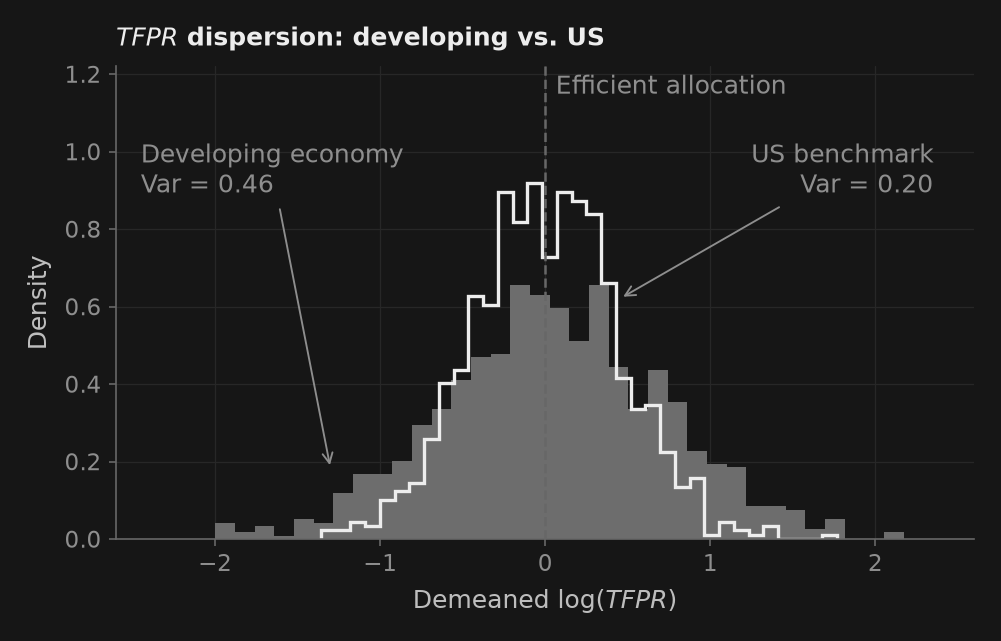

In [8]:
# Set random seed for scientific reproducibility
np.random.seed(42)
N = 1000
sigma_elasticity = 3.0

# 1. Calibrate empirical TFPR dispersion benchmarks (Hsieh-Klenow 2009, Table II)
std_tfpr_us = 0.45                                         # US manufacturing benchmark
std_tfpr_dev = 0.68                                        # Developing economy benchmark (China / India)

# 2. Simulate firm cross-section
log_tfpq = np.random.normal(0.0, 0.80, N)                  # Physical productivity log(TFPQ)
log_tfpr_dev = np.random.normal(0.0, std_tfpr_dev, N)      # Distorted revenue productivity
log_tfpr_us = np.random.normal(0.0, std_tfpr_us, N)        # Benchmark revenue productivity

var_dev = float(np.var(log_tfpr_dev))
var_us = float(np.var(log_tfpr_us))

# 3. Compute counterfactual aggregate TFP gains
tfp_gain_to_us = np.exp(0.5 * sigma_elasticity * (var_dev - var_us)) - 1.0
tfp_gain_to_efficient = np.exp(0.5 * sigma_elasticity * var_dev) - 1.0

print(f"Empirical Var(log TFPR): Developing = {var_dev:.4f} vs US Benchmark = {var_us:.4f}")
print(f"Counterfactual TFP Gain from closing distortion gap to US: {tfp_gain_to_us * 100:.1f}%")
print(f"Potential TFP Gain from full allocative efficiency: {tfp_gain_to_efficient * 100:.1f}%")

# 4. Objective verification assertions
assert var_dev > var_us, "Developing economy must exhibit greater TFPR dispersion"
assert 0.35 <= tfp_gain_to_us <= 0.60, f"Expected TFP gain in [35%, 60%], got {tfp_gain_to_us*100:.1f}%"
assert tfp_gain_to_efficient > 0.80, f"Full allocative efficiency must boost TFP > 80%, got {tfp_gain_to_efficient*100:.1f}%"

# 5. Visualize empirical TFPR distributions
fig, ax = _nbstyle.figura()
ax.hist(log_tfpr_dev, bins=35, density=True, color=_nbstyle.tono(0.45))
ax.hist(log_tfpr_us, bins=35, density=True, histtype="step", lw=1.6,
        color=_nbstyle.TINTA)
ax.axvline(0.0, color=_nbstyle.SPINE, linestyle="--", linewidth=1.2)
ax.set_xlim(-2.6, 2.6)
ax.set_ylim(0.0, 1.22)
ax.set_xlabel(r"Demeaned $\log(TFPR)$")
ax.set_ylabel("Density")
ax.set_title(r"$TFPR$ dispersion: developing vs. US")
ax.annotate(f"Developing economy\nVar = {var_dev:.2f}", xy=(-1.30, 0.18),
            xytext=(-2.45, 0.95), ha="left", va="center",
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.annotate(f"US benchmark\nVar = {var_us:.2f}", xy=(0.45, 0.62),
            xytext=(2.35, 0.95), ha="right", va="center",
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.annotate("Efficient allocation", xy=(0.0, 1.0), xycoords=("data", "axes fraction"),
            xytext=(5, -4), textcoords="offset points", ha="left", va="top",
            color=_nbstyle.NOTA)
plt.show()


### Empirical Synthesis: Allocative Efficiency, Zombie Lending, and the Macro-Development Puzzle

This empirical counterfactual illuminates why resource misallocation is central to modern macroeconomics:

1. **Explaining Cross-Country Income Differences**: Standard neoclassical growth models struggled to explain why emerging economies produce so little output per worker despite massive physical capital investments. Hsieh and Klenow (2009) demonstrated that **between 30% and 60% of the aggregate TFP gap** between developing nations and the United States is driven by within-industry misallocation of capital and labor, rather than missing technology.
2. **The Anatomy of Distortionary Wedges**:
   - **Capital Frictions**: State-directed banking systems and subsidized loans funnel cheap credit to low-productivity, state-favored or politically connected firms, while dynamic private entrepreneurs face exorbitant interest rates.
   - **Informality and Size Distortions**: Regulatory thresholds (e.g., labor inspection laws triggered above 20 employees or tax audits on registered businesses) incentivize productive firms to artificially stay small or operate informally.
   - **Zombie Conglomerates**: Inadequate bankruptcy codes permit chronically insolvent firms to stay alive, locking up productive real estate, skilled labor, and machinery.
3. **Connection to the Curriculum**: Firm-level selection and misallocation form the supply-side counterpart to household wealth heterogeneity in **Aiyagari-Bewley** models (`T06_A_wealth_inequality`) and labor matching frictions in **Diamond-Mortensen-Pissarides** search models (`T08_A_labor_flows`).